In [4]:
#from original notebook:
import requests
import json
import rasterio as rio
from rasterio.plot import show
from rasterio.merge import merge
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes 
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import numpy as np
from pathlib import Path
import os
from urllib.request import urlretrieve
from json import dumps
import earthaccess
from earthaccess import Auth, DataCollections, DataGranules, Store

from numpy.lib.stride_tricks import sliding_window_view

from matplotlib import pyplot as plt
from matplotlib import patches
from pyproj import Transformer
import plotly.graph_objects as go
import plotly.express as px
from tqdm import tqdm
from loguru import logger

from pyproj import Transformer
from datetime import datetime
mapbox_access_token = open(".mapbox_token").read()
px.set_mapbox_access_token(mapbox_access_token)

In [62]:
# Split Earth into grid 6 x 6 degrees
# Spatial coverage of OPERA: N: 84° S: -84° E: 180° W: -180°

# Split globe spatially

In [63]:
# Create grid of lat lons
lats,lons = np.mgrid[-84:84:6, -180:180:6]
latlons_grid = np.stack((lats, lons), axis=-1)
latlons_grid.shape

(28, 60, 2)

In [64]:
# Split grid into 2x2 boxes to define area
grids = sliding_window_view(latlons_grid, (2, 2,2))[::2,::2,0,:,:].reshape((-1,2,2,2))
bboxes = []
bboxes_opera = []
for g in grids:
    bbox_o = np.diagonal(g).T   # only get SW and NE coordinates
    bboxes_opera.append(bbox_o[:,::-1].flatten()) # witch to lon1,lat1,lon2,lat2
    bbox_lats = g.flatten()[::2]
    bbox_lons = g.flatten()[1::2]
    bboxes.append([bbox_lats, bbox_lons])   # for visualization
bboxes = np.array(bboxes)
bboxes_opera = np.array(bboxes_opera)
grids.shape, bboxes.shape, bboxes_opera.shape

((420, 2, 2, 2), (420, 2, 4), (420, 4))

In [65]:
auth = earthaccess.login(strategy="interactive", persist=True)

for i in range(len(bboxes_opera)):
    if i<420:
        continue
    print(i)
    results_opera = earthaccess.search_data(
        concept_id="C2617126679-POCLOUD", 
        bounding_box=tuple(bboxes_opera[i]), 
        # temporal=("2023-05-01","2023-05-31")
        temporal=("2023-04-04","2024-03-14")
    )
    if len(results_opera)==0:
        continue
    
    results_sentinel = earthaccess.search_data(
        concept_id="C2021957295-LPCLOUD", 
        bounding_box=tuple(bboxes_opera[i]), 
        # temporal=("2023-05-01","2023-05-31")
        temporal=("2023-04-04","2024-03-14")
    )
    results_landsat = earthaccess.search_data(
        concept_id="C2021957657-LPCLOUD", 
        bounding_box=tuple(bboxes_opera[i]), 
        # temporal=("2023-05-01","2023-05-31")
        temporal=("2023-04-04","2024-03-14")
    )
    if (len(results_sentinel)==0) and (len(results_landsat)==0):
        continue


    opera_links = []
    for g in results_opera:
        for l in earthaccess.results.DataGranule.data_links(g):
            opera_links.append(l)

    landsat_links = []
    for g in results_landsat:
        for l in earthaccess.results.DataGranule.data_links(g):
            landsat_links.append(l)

    sentinel_links = []
    for g in results_sentinel:
        for l in earthaccess.results.DataGranule.data_links(g):
            sentinel_links.append(l)
            
    # out_path = os.path.join("links", f"b{i:03d}-opera.npy")   
    # with open(out_path, "wb") as f:
    #     np.savez(
    #         f,
    #         opera_links=opera_links,
    #         landsat_links=landsat_links,
    #         sentinel_links=sentinel_links,
    #         bboxes=bboxes_opera,
    #     )

    l_links = []
    for l in landsat_links:
        if not l.endswith("B01.tif"):
            continue
        l_links.append(l)

    s_links = []
    for l in sentinel_links:
        if not l.endswith("B01.tif"):
            continue
        s_links.append(l)


    opera_to_hls_mapping = {}
    ctr = 0
    for o_link in tqdm(opera_links):
        if not o_link.endswith("B01_WTR.tif"):
            continue
        ctr += 1
        opera_sat = o_link.split("_")[-5]
        opera_tile_id = o_link.split("_")[-8]
        opera_datetime = o_link.split("_")[-7]
        opera_year = opera_datetime[:4]
        opera_date = opera_datetime.split("T")[0]
        opera_time = opera_datetime.split("T")[1].strip("Z")
        datetime_object = datetime.strptime(opera_date, '%Y%m%d')
        opera_day_of_year = datetime_object.timetuple().tm_yday
        
        hls_datetime = f"{opera_year}{opera_day_of_year:03d}T{opera_time}"

        if opera_sat.startswith("L"): # landsat
            sat_links = l_links
        else:
            sat_links = s_links
        
        hls_subset = f".{opera_tile_id}.{hls_datetime}"
        for hls_link in sat_links:
            if hls_subset in hls_link:
                opera_to_hls_mapping[o_link] = hls_link
                # print(hls_subset, hls_link)
                break
    logger.debug(f"Found {len(opera_to_hls_mapping)} matches.")
    out_path = os.path.join("links", f"b{i:03d}-opera.npy")   
    with open(out_path, "wb") as f:
        np.savez(
            f,
            opera_links=opera_links,
            landsat_links=landsat_links,
            sentinel_links=sentinel_links,
            bboxes=bboxes_opera,
            opera_to_hls_mapping=opera_to_hls_mapping,
        )
    # break


# Randomly sample dates per tile ID

In [66]:

num_samples_per_tile = 20   # means per tile ID, sample 20 different dates (~52 weeks in a year, so ~1 sample every 2 weeks)
ctr = 0
for i, fname in enumerate(os.listdir("links")):
    fp = os.path.join("links", fname)
    print(i, fp)
    space_group = fname.split("-")[0]
    with open(fp, "rb") as f:
        npzfile = np.load(f, allow_pickle=True)
        opera_to_hls_mapping = npzfile["opera_to_hls_mapping"]
        bboxes = npzfile["bboxes"]
        ctr += len(opera_to_hls_mapping[()])

    opera_downloads = []
    hls_downloads = []
    tile_id_dates = {}
    for k,v in opera_to_hls_mapping[()].items():
        opera_sat = k.split("_")[-5]
        opera_tile_id = k.split("_")[-8]
        opera_datetime = k.split("_")[-7]
        if opera_tile_id not in tile_id_dates:
            tile_id_dates[opera_tile_id] = []
        tile_id_dates[opera_tile_id].append({
            "datetime": opera_datetime,
            "opera_link": k,
            "hls_link": v,
        })

    # Sample random dates per tile ID
    tile_id_dates_copy = tile_id_dates.copy()
    for k,v in tile_id_dates_copy.items():
        num_samps = np.minimum(len(v), num_samples_per_tile)
        choices = np.random.choice(v, size=num_samps, replace=False)
        tile_id_dates[k] = choices
    
    # Save sampled tiles
    out_path = os.path.join("sampled_links", f"{space_group}.npy")   
    with open(out_path, "wb") as f:
        np.savez(
            f,
            tile_id_dates=tile_id_dates,
            bboxes=bboxes,
        )

0 links/b069-opera.npy
1 links/b072-opera.npy
2 links/b075-opera.npy
3 links/b081-opera.npy
4 links/b088-opera.npy
5 links/b090-opera.npy
6 links/b099-opera.npy


7 links/b108-opera.npy
8 links/b109-opera.npy
9 links/b117-opera.npy
10 links/b119-opera.npy
11 links/b120-opera.npy
12 links/b128-opera.npy
13 links/b129-opera.npy
14 links/b130-opera.npy
15 links/b136-opera.npy
16 links/b137-opera.npy
17 links/b144-opera.npy
18 links/b145-opera.npy
19 links/b146-opera.npy
20 links/b147-opera.npy
21 links/b148-opera.npy
22 links/b149-opera.npy
23 links/b150-opera.npy
24 links/b151-opera.npy
25 links/b152-opera.npy
26 links/b153-opera.npy
27 links/b154-opera.npy
28 links/b159-opera.npy
29 links/b160-opera.npy
30 links/b161-opera.npy
31 links/b162-opera.npy
32 links/b166-opera.npy
33 links/b167-opera.npy
34 links/b168-opera.npy
35 links/b169-opera.npy
36 links/b170-opera.npy
37 links/b174-opera.npy
38 links/b175-opera.npy
39 links/b176-opera.npy
40 links/b177-opera.npy
41 links/b178-opera.npy
42 links/b179-opera.npy
43 links/b180-opera.npy
44 links/b181-opera.npy
45 links/b182-opera.npy
46 links/b183-opera.npy
47 links/b188-opera.npy
48 links/b189-opera

# Check number of tiles to download

In [67]:
num_dls = 0
num_tiles = 0
tile_ids = []
for i, fname in enumerate(os.listdir("sampled_links")):
    fp = os.path.join("sampled_links", fname)
    space_group = fname.split(".")[0]
    
    with open(fp, "rb") as f:
        data = np.load(f, allow_pickle=True)
        tile_id_dates = data["tile_id_dates"][()]
        bboxes = data["bboxes"]
    num_tiles += len(tile_id_dates)
    for k,v in tile_id_dates.items():
        tile_id_num = len(tile_ids)
        tile_ids.append(k)
        num_dls += len(v)
        
        # Save sampled tiles (to facilitate parallel dowload)
        out_path = os.path.join("sampled_per_tile_id", f"{tile_id_num}.npy")   
        with open(out_path, "wb") as f:
            np.savez(
                f,
                tile_id=k,
                links=v,
                space_group=space_group,
            )
print(num_tiles, num_dls)   # 7163 tile IDs, 143,190 tiles

7163 143190


In [68]:
fp = "sampled_per_tile_id/0.npy"
with open(fp, "rb") as f:
    npzfile = np.load(f, allow_pickle=True)
    tile_id = npzfile["tile_id"][()]
    links = npzfile["links"][()]
    space_group = npzfile["space_group"][()]
space_group, tile_id, links

('b069',
 'T19FFV',
 array([{'datetime': '20231222T135701Z', 'opera_link': 'https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/OPERA_L3_DSWX-HLS_PROVISIONAL_V1/OPERA_L3_DSWx-HLS_T19FFV_20231222T135701Z_20231224T080934Z_S2A_30_v1.0_B01_WTR.tif', 'hls_link': 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSS30.020/HLS.S30.T19FFV.2023356T135701.v2.0/HLS.S30.T19FFV.2023356T135701.v2.0.B01.tif'},
        {'datetime': '20231221T134415Z', 'opera_link': 'https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/OPERA_L3_DSWX-HLS_PROVISIONAL_V1/OPERA_L3_DSWx-HLS_T19FFV_20231221T134415Z_20231230T021056Z_L8_30_v1.0_B01_WTR.tif', 'hls_link': 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T19FFV.2023355T134415.v2.0/HLS.L30.T19FFV.2023355T134415.v2.0.B01.tif'},
        {'datetime': '20240126T135659Z', 'opera_link': 'https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/OPERA_L3_DSWX-HLS_PROVISIONAL_

# Download Data

In [77]:
opera_bands = ["B01_WTR", "B03_CONF", "B08_SHAD", "B09_CLOUD"]
landsat_bands = ["B02", "B03", "B04", "B05", "B06", "B07", "Fmask"] # landsat (B,G,R,NIR,SWIR1,SWIR2)
sentinel_bands = ["B02", "B03", "B04", "B8A", "B11", "B12", "Fmask"]

ctr = 0
# for i, fname in enumerate(os.listdir("sampled_links")):
for i in range(7163):
    logger.debug(f"Processing index {i}")
    fname = f"{i}.npy"
    fp = os.path.join("sampled_per_tile_id", fname)
    with open(fp, "rb") as f:
        npzfile = np.load(f, allow_pickle=True)
        tile_id = npzfile["tile_id"][()]
        links = npzfile["links"][()]
        space_group = npzfile["space_group"][()]

    opera_downloads = []
    hls_downloads = []

    for group in links:
        opera_link = group["opera_link"]
        opera_sat = opera_link.split("_")[-5]
        for b in opera_bands:
            link = opera_link.replace("B01_WTR", b)
            opera_downloads.append(link)

        if opera_sat.startswith("L"):
            hls_bands = landsat_bands
        else:
            hls_bands = sentinel_bands
        
        hls_link = group["hls_link"]
        for b in hls_bands:
            link = hls_link.replace("B01", b)
            hls_downloads.append(link)

    # earthaccess.download(opera_downloads, f"./data_downloads/{space_group}/opera")
    # earthaccess.download(hls_downloads, f"./data_downloads/{space_group}/hls")
    # break
print(ctr)  # 989479 granules/tiles

2024-03-17 21:46:03.368 | DEBUG    | __main__:<module>:8 - Processing index 0
2024-03-17 21:46:03.374 | DEBUG    | __main__:<module>:8 - Processing index 1
2024-03-17 21:46:03.378 | DEBUG    | __main__:<module>:8 - Processing index 2
2024-03-17 21:46:03.382 | DEBUG    | __main__:<module>:8 - Processing index 3
2024-03-17 21:46:03.387 | DEBUG    | __main__:<module>:8 - Processing index 4
2024-03-17 21:46:03.391 | DEBUG    | __main__:<module>:8 - Processing index 5
2024-03-17 21:46:03.396 | DEBUG    | __main__:<module>:8 - Processing index 6
2024-03-17 21:46:03.400 | DEBUG    | __main__:<module>:8 - Processing index 7
2024-03-17 21:46:03.406 | DEBUG    | __main__:<module>:8 - Processing index 8
2024-03-17 21:46:03.411 | DEBUG    | __main__:<module>:8 - Processing index 9
2024-03-17 21:46:03.417 | DEBUG    | __main__:<module>:8 - Processing index 10
2024-03-17 21:46:03.426 | DEBUG    | __main__:<module>:8 - Processing index 11
2024-03-17 21:46:03.432 | DEBUG    | __main__:<module>:8 - Pro

In [70]:
len(hls_downloads), len(np.unique(np.array(hls_downloads))), len(opera_downloads), len(np.unique(np.array(opera_downloads)))

(140, 140, 80, 80)

# Generate train data

In [47]:
DATA_DIR = "data_downloads/"
OUT_DATASET_DIR = "/scratch/workspace/rdaroya_umass_edu-water/hls_data/multitask_data_opera"
nodata_val=-9999
opera_bands = ["B01_WTR", "B03_CONF", "B08_SHAD", "B09_CLOUD"]
landsat_bands = ["B02", "B03", "B04", "B05", "B06", "B07"]#, "Fmask"] # landsat (B,G,R,NIR,SWIR1,SWIR2)
sentinel_bands = ["B02", "B03", "B04", "B8A", "B11", "B12"]#, "Fmask"]


i = 2000
fname = f"{i}.npy"
fp = os.path.join("sampled_per_tile_id", fname)
with open(fp, "rb") as f:
    npzfile = np.load(f, allow_pickle=True)
    tile_id = npzfile["tile_id"][()]
    links = npzfile["links"][()]
    space_group = npzfile["space_group"][()]

samp_out_dir = os.path.join(OUT_DATASET_DIR, space_group)
if not os.path.exists(samp_out_dir):
    os.makedirs(samp_out_dir, exist_ok=True)

In [48]:



# center crop each tile (1574+512 = 2086) -- 1574:2086
for group_ctr,group in enumerate(links):
    opera_samp = group["opera_link"].split("/")[-1]
    opera_prefix = opera_samp.split("_")[:-2]
    opera_prefix = "_".join(opera_prefix)
    logger.debug(f"opera_prefix: {opera_prefix}, opera_samp: {opera_samp}")
    opera_link = group["opera_link"]
    opera_sat = opera_link.split("_")[-5]


    # Process opera bands to get labels and other data (get high CONF water + sunmask, snowice, etc)
    # Get High Confidence water pixels
    fp_dir = os.path.join(DATA_DIR, space_group, "opera")
    opera_water_fp = os.path.join(fp_dir, f"{opera_prefix}_B01_WTR.tif")
    water_band = rio.open(opera_water_fp).read(1)[1574:2086, 1574:2086]
    assert water_band.shape==(512,512)  # get 1 (open water), 2 (partial water), 254 (ocean)
    water = np.where(water_band==1, 1, 0) + np.where(water_band==2, 1, 0) + np.where(water_band==254, 1, 0)   #1=open water; 2=partial surface water; 254=ocean masked
    water = np.where(water>0, 1, 0)
    # print(water_band.shape, water.shape, np.unique(water_band))

    opera_conf_fp = os.path.join(fp_dir, f"{opera_prefix}_B03_CONF.tif")
    conf_band = rio.open(opera_conf_fp).read(1)[1574:2086, 1574:2086]
    assert conf_band.shape==(512,512)   # get 1 (open water high conf), 3 (partial surface water conservative), 254 (ocean)
    high_conf = np.where(conf_band==1, 1, 0) + np.where(conf_band==3, 1, 0) + np.where(conf_band==254, 1, 0)
    high_conf = np.where(high_conf>0, 1, 0)
    # print(high_conf.shape, np.unique(conf_band))

    high_conf_water = high_conf * water
    assert high_conf_water.shape == (512,512)


    # Get cloud mask
    opera_cloud_fp = os.path.join(fp_dir, f"{opera_prefix}_B09_CLOUD.tif")
    cloud_band = rio.open(opera_cloud_fp).read(1)[1574:2086, 1574:2086]
    assert cloud_band.shape==(512,512)
    cloud_data = np.where(cloud_band==4, 1, 0)

    # Get cloudshadow mask
    cloudshadow_data = np.where(cloud_band==1, 1, 0)

    # Get snow/ice mask
    snowice_data = np.where(cloud_band==2, 1, 0)


    # Get sunmask
    opera_sunmask_fp = os.path.join(fp_dir, f"{opera_prefix}_B08_SHAD.tif")
    sunmask_band = rio.open(opera_sunmask_fp).read(1)[1574:2086, 1574:2086]
    assert sunmask_band.shape==(512,512)
    sunmask_data = sunmask_band


    if opera_sat.startswith("L"):
        hls_feat_bands = landsat_bands
    else:
        hls_feat_bands = sentinel_bands

    # Process hls bands to get features
    hls_samp = group["hls_link"].split("/")[-1]
    hls_prefix = hls_samp.split(".")[:-2]
    hls_prefix = ".".join(hls_prefix)
    logger.debug(f"hls_prefix: {hls_prefix}, hls_samp: {hls_samp}")
    fp_dir = os.path.join(DATA_DIR, space_group, "hls")
    feat_bands_data = []
    try:
        for band in hls_feat_bands:
            hls_fp = os.path.join(fp_dir, f"{hls_prefix}.{band}.tif")
            dataset = rio.open(hls_fp)
            data = dataset.read(1)[1574:2086, 1574:2086]
            assert data.shape == (512,512)
            feat_bands_data.append(data)
            # print(hls_fp, data.shape)
    except rasterio.errors.RasterioIOError:
        logger.error(f"{hls_fp} cannot be read [space_group={space_group}]")
        continue
    features = np.stack(feat_bands_data, axis=-1)   # stack in 3rd axis
    assert features.shape == (512,512,6)
    if np.sum(np.where(features!=nodata_val, 1,0)) == 0:
        logger.error(f"{hls_fp} has all no data [{nodata_val}] features. Skipping.")
        continue

    # Process hls bands to get Fmask (for comparison later -- no need to postprocess; just save crop)
    fmask_fp = os.path.join(DATA_DIR, space_group, "hls", f"{hls_prefix}.Fmask.tif")  # 14 is FMask (UPDATE: 16 is FMask)
    try:
        fmask_dataset = rio.open(fmask_fp)
    except rasterio.errors.RasterioIOError:
        logger.error(f"{fmask_fp} cannot be read [row_ctr={row_ctr}, row_num={row_num}]")
        continue
    fmask_data = fmask_dataset.read(1)
    assert np.max(fmask_data) <= 255
    assert np.min(fmask_data) >= 0
    fmask_data = fmask_data.astype(np.uint8)[1574:2086, 1574:2086]
    assert fmask_data.shape == (512,512)


    # TODO: check outputs


    # Generate lat/lon of middle of tiles
    ul = [dataset.bounds.left, dataset.bounds.top]
    ur = [dataset.bounds.right, dataset.bounds.top]
    lr = [dataset.bounds.right, dataset.bounds.bottom]
    ll = [dataset.bounds.left, dataset.bounds.bottom]
    transformer = Transformer.from_crs(dataset.crs, "EPSG:4326")    # lat/lon is EPSG 4326
    lats, lons = transformer.transform([ul[0], ur[0], lr[0], ll[0], ul[0]], [ul[1], ur[1], lr[1], ll[1], ul[1]])
    lat_c = (lats[0]+lats[2])/2
    lon_c = (lons[1]+lons[0])/2
    print(f"lat_c: {lat_c}, lon_c: {lon_c}")

    # TODO: save outputs
    out_path = os.path.join(OUT_DATASET_DIR, space_group, f"{i}_{tile_id}_{group_ctr}.npy")   # Save with same idx in filtered csv
    with open(out_path, "wb") as f:
        np.savez(
            f,
            space_group=space_group,
            tile_id=tile_id,
            date_str=group["datetime"],
            features=features,
            fmask_data=fmask_data,

            mid_latlon=[lat_c, lon_c],

            water_mask=high_conf_water,
            snowice_mask=snowice_data,
            cloudshadow_mask=cloudshadow_data,
            sun_mask=sunmask_data,
            cloud_mask=cloud_data,
            # cirrus_mask=cirrus_mask,
        )
    logger.debug(f"Saved features to {out_path}")
    break

2024-03-19 15:17:51.157 | DEBUG    | __main__:<module>:6 - opera_prefix: OPERA_L3_DSWx-HLS_T37NHC_20230611T071621Z_20230613T183623Z_S2A_30_v1.0, opera_samp: OPERA_L3_DSWx-HLS_T37NHC_20230611T071621Z_20230613T183623Z_S2A_30_v1.0_B01_WTR.tif


2024-03-19 15:17:52.938 | DEBUG    | __main__:<module>:61 - hls_prefix: HLS.S30.T37NHC.2023162T071621.v2.0, hls_samp: HLS.S30.T37NHC.2023162T071621.v2.0.B01.tif
2024-03-19 15:17:59.225 | DEBUG    | __main__:<module>:129 - Saved features to /scratch/workspace/rdaroya_umass_edu-water/hls_data/multitask_data_opera/b228/2000_T37NHC_0.npy


lat_c: 2.2141852201919217, lon_c: 42.19098946787041


In [53]:
fp = "/scratch/workspace/rdaroya_umass_edu-water/hls_data/multitask_data_opera/b228/2000_T37NHC_0.npy"

masks = ["features", "snowice_mask", "water_mask", "cloudshadow_mask", "cloud_mask", "sun_mask"]
    
with open(fp, "rb") as f:
    npzfile = np.load(f, allow_pickle=True)
    features = npzfile["features"]  # (512,512,6)
    snowice_mask = npzfile["snowice_mask"]
    water_mask = npzfile["water_mask"]  # (512,512)
    cloudshadow_mask = npzfile["cloudshadow_mask"]  # (512,512)
    cloud_mask = npzfile["cloud_mask"]  # (512,512)
    sun_mask = npzfile["sun_mask"]  # (512,512)
    for m in masks[1:]:
        mask = npzfile[m]
        print(f"{m}. vals: {np.unique(mask)}")
        plt.imshow(mask, vmin=0, vmax=1)
        plt.savefig(f"{m}.jpg", bbox_inches="tight")
        plt.close()

snowice_mask. vals: [0 1]
water_mask. vals: [0 1]
cloudshadow_mask. vals: [0 1]
cloud_mask. vals: [0 1]
sun_mask. vals: [0 1]


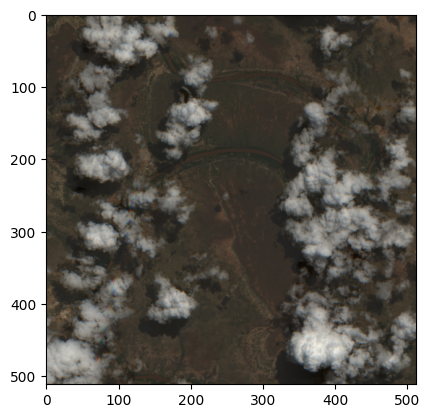

In [58]:


feats_tmp = np.where(features==nodata_val, np.nanmax(features), features)
feats_min = np.nanmin(feats_tmp)
feats_tmp = np.where(features==nodata_val, feats_min, features)    # replace nodata values with minimum
feats_tmp = np.where(np.isnan(feats_tmp), feats_min, feats_tmp)    # replace nan values with minimum
feats_tmp = np.nan_to_num(feats_tmp, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
feats_tmp = (feats_tmp - np.nanmin(feats_tmp)) / np.maximum((np.nanmax(feats_tmp) - np.nanmin(feats_tmp)), 1)
rgb = feats_tmp[:,:,:3][:,:,::-1]
# rgb[:,:,0] = rgb[:,:,0]*0.7 + sun_mask
plt.imshow(rgb)

In [27]:
np.sum(water_gt), np.unique(water_band), np.max(water_band), np.min(water_band)

(0, array([  0, 253], dtype=uint8), 253, 0)

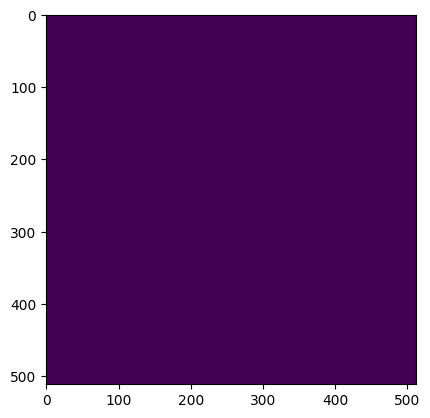

In [28]:
plt.imshow(water_gt, vmax=1, vmin=0)

In [16]:
# space_group, 
link_samp = links[0]

('HLS.S30.T19FFV.2023356T135701.v2.0',
 'HLS.S30.T19FFV.2023356T135701.v2.0.B01.tif')

# Visualization

In [75]:
# Plot bboxes
token = open(".mapbox_token").read() # you need your own token
fig = go.Figure(go.Scattermapbox(
        mode = "markers+text+lines",
        # lon = [-75, -80, -50, -75], lat = [45, 20, -20, 45],
        lat=bboxes[0][0], lon=bboxes[0][1],
        marker = {'size': 5, },
        # text = ["Bus", "Harbor", "airport"],textposition = "bottom right"
    ))
for lat, lon in bboxes[1:10]:
    fig.add_trace(go.Scattermapbox(
        mode = "markers+text+lines",
        # lon = [-75, -80, -50, -75], lat = [45, 20, -20, 45],
        lat=lat, lon=lon,
        marker = {'size': 5, },
        # text = ["Bus", "Harbor", "airport"],textposition = "bottom right"
    ))

fig.update_layout(
    mapbox = {
        'accesstoken': token,
        'style': "outdoors", 'zoom': 0.7},
    showlegend = False)

fig.show()

ValueError: 
    Invalid value of type 'numpy.int64' received for the 'lat' property of scattermapbox
        Received value: -180

    The 'lat' property is an array that may be specified as a tuple,
    list, numpy array, or pandas Series